## Analysis of Results

#### Setup

In [2]:
### Imports ###
import os
import shutil
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.lines as mlines
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path
from scipy.stats import norm, qmc
import SALib
from SALib.sample import sobol
from SALib.analyze import sobol 
from eppy.modeleditor import IDF
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


In [3]:
work_dir = "/jumbo/keller-lab/Jeremy_Wang/eplus_sa/scripts/main" # Change this to your working directory
idd_file_path = "/jumbo/keller-lab/Applications/EnergyPlus-24-1-0/Energy+.idd" # Change to your IDD file path
base_output_idf_dir = os.path.join(work_dir, "randomized_idfs_sobol") # change base output to sobol sequence generated
weather_file = os.path.join(
    work_dir, "weather_data",
    "USA_IL_Chicago-OHare-Intl-AP.725300_AMY_2023.epw"
)
base_output_sim_dir = os.path.join(work_dir, "output_sobol") # output_sobol stores values
os.chdir(work_dir) # Set working directory
figure_dir = os.path.join(work_dir, "figures_sobol") # figure directory for sobol sequence generated
os.makedirs(figure_dir, exist_ok=True)

### Load Simulation Results for all seeds

In [3]:
# number of sims per seed
num_simulations = 30000

# list your seed directories
seeds = [f"seed_{i}" for i in range(1,6)]

# where your outputs live
output_base = os.path.join(work_dir, "output_sobol")

def read_csv_for_sim(task):
    seed, sim_id = task
    folder = f"randomized_{sim_id}" # sim id is number run within the seed
    csv_file = os.path.join(output_base, seed, folder, "eplusmtr.csv")
    # skip if missing or zero‐byte
    if not os.path.isfile(csv_file) or os.path.getsize(csv_file) == 0:
        return None
    try:
        df = pd.read_csv(csv_file)
    except pd.errors.EmptyDataError:
        return None
    df["Simulation_ID"] = sim_id
    df["seed"]          = seed
    return df

#### Checking to see where files are missing

In [4]:
# # build the full list of (seed, sim_id) pairs
# tasks = [(seed, i) for seed in seeds for i in range(1, num_simulations+1)]

# max_workers = os.cpu_count() or 4 # returns the number of available cpu cores
# print(f"Reading {len(tasks)} files across {len(seeds)} seeds using {max_workers} workers...")

# # checking which files are missing
# missing_files = pd.DataFrame(columns = ['seed', 'sim_id'])
# with ProcessPoolExecutor(max_workers=max_workers) as executor:
#     future_to_task = {executor.submit(read_csv_for_sim, t): t for t in tasks} # for every task (seed, i) combo, tells the executor to read csv
#     for future in as_completed(future_to_task): # as soon as completed, append df into a bigger output
#         df = future.result()
#         seed, sim_id = future_to_task[future]
#         if df is None:
#             new_row = pd.DataFrame([{'seed': seed, 'sim_id': sim_id}])
#             missing_files = pd.concat([missing_files, new_row], ignore_index=True)
#             print(f"Skipping empty/missing file: {seed}/randomized_{sim_id}/eplusmtr.csv")

# if missing_files.empty:
#     print("No missing files detected.")


In [5]:
# # --- Simulation function ---
# # output_idf_dir is the location where the idf is currently stored
# # output_sim_dir is where the outputs are saved to
# def run_single_simulation(idf_file, output_idf_dir, output_sim_dir):
#     # Ensure EnergyPlus IDD
#     IDF.setiddname(idd_file_path)
#     # Create per-model output folder
#     case_name = os.path.splitext(idf_file)[0]
#     sim_dir = os.path.join(output_sim_dir, case_name)

#     # Remove existing sim_dir if it exists to avoid conflicts
#     if os.path.exists(sim_dir):
#         shutil.rmtree(sim_dir)
#     os.makedirs(sim_dir, exist_ok=True)

#     # Load and save a validated copy (saving a copy of the idf in the output folder)
#     src = os.path.join(output_idf_dir, idf_file)
#     idf = IDF(src)
#     validated = os.path.join(sim_dir, idf_file)
#     idf.save(validated)
#     # Run EnergyPlus
#     subprocess.run([
#         '/jumbo/keller-lab/Applications/EnergyPlus-24-1-0/energyplus',
#         '--weather', weather_file,
#         '--output-directory', sim_dir,
#         '--idd', idd_file_path,
#         # annual indicates annual run, readvars processes outputs
#         '--annual', '--readvars', validated # validated is the idf
#     ], check=True)


# for i in range(len(missing_files)):
#     seed = missing_files.iloc[i]['seed']
#     file = missing_files.iloc[i]['sim_id']
#     idf_file = f"randomized_{file}.idf"
#     output_idf_dir = os.path.join(base_output_idf_dir, f"{seed}")
#     output_sim_dir = os.path.join(base_output_sim_dir, f"{seed}")

#     run_single_simulation(idf_file, output_idf_dir, output_sim_dir)
#     print(f"Completed simulation for {idf_file} in {seed}")


### Loading Simulation Results ###

In [6]:

all_dfs = []
tasks = [(seed, i) for seed in seeds for i in range(1, num_simulations+1)]
max_workers = os.cpu_count() or 4 # returns the number of available cpu cores

with ProcessPoolExecutor(max_workers=max_workers) as executor:
    future_to_task = {executor.submit(read_csv_for_sim, t): t for t in tasks} # for every task (seed, i) combo, tells the executor to read csv
    for future in as_completed(future_to_task): # as soon as completed, append df into a bigger output
        df = future.result()
        seed, sim_id = future_to_task[future]
        if df is not None:
            all_dfs.append(df)

# combine into one big DataFrame
# # rows = ((num_simulations * num_seeds) - (missing files)) * 12 months
combined_df = pd.concat(all_dfs, ignore_index=True)

In [7]:
# analysis_sim_dir = os.path.join(work_dir, "analysis_sobol")
# os.makedirs(analysis_sim_dir, exist_ok=True)

# # --- Clean analysis output directory ---
# for fn in os.listdir(analysis_sim_dir):
#     path = os.path.join(analysis_sim_dir, fn)
#     if os.path.isfile(path) or os.path.islink(path): 
#         os.unlink(path)
#     elif os.path.isdir(path):
#         shutil.rmtree(path)

# # --- CSV output directory ---
# csv_out = os.path.join(analysis_sim_dir, "output_csv")
# if os.path.isdir(csv_out): shutil.rmtree(csv_out) # removing the folder if it already exists
# os.makedirs(csv_out, exist_ok=True)

In [9]:
### Convert numbers into numerics ###

# Convert columns to numeric
numeric_cols = [
    "Electricity:Facility [J](Monthly)", "Electricity:Building [J](Monthly)", "InteriorLights:Electricity [J](Monthly)",
    "Electricity:Facility [J](RunPeriod)", "Electricity:Building [J](RunPeriod)", "InteriorLights:Electricity [J](RunPeriod)",
    "Electricity:HVAC [J](Monthly)", "NaturalGas:Facility [J](Monthly)", "NaturalGas:HVAC [J](Monthly)",
    "Electricity:HVAC [J](RunPeriod)", "NaturalGas:Facility [J](RunPeriod)", "NaturalGas:HVAC [J](RunPeriod)"
]

for col in numeric_cols:
    if col in combined_df:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

# Unit conversions (adds columns in KJ, KWh, BTU)
for col in list(combined_df):
    if col.endswith("[J](Monthly)") or col.endswith("[J](RunPeriod)"):
        combined_df[col.replace("[J]", "[KJ]")] = combined_df[col] / 1e3
        combined_df[col.replace("[J]", "[kWh]")] = combined_df[col] / 3.6e6

BTU_conv = 0.000947817
for col in list(combined_df):
    if "[J](" in col and ("HVAC" in col or "NaturalGas" in col):
        combined_df[col.replace("[J]", "[BTU]")] = combined_df[col] * BTU_conv

# saving converted combined_df values to csv in the folder
# combined_df.to_csv(os.path.join(csv_out, "combined_sims.csv"), index=False, float_format="%.2f")

# --- Define month order ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

combined_df["Date/Time"] = pd.Categorical(
    combined_df["Date/Time"], categories=month_order, ordered=True
)

In [ ]:
# ### saving csv files by seed ###

# # For a variable number of seeds (e.g., 1 to 20)
# max_seed = 5  # Change this to the number of seeds you have

# for i in range(1, max_seed + 1):
#     seed_name = f"seed_{i}"
#     # Check if this seed exists in the data before creating the variable
#     if seed_name in combined_df["seed"].unique():
#         globals()[seed_name] = combined_df[combined_df["seed"] == seed_name] # creates a df for each seed

# for i in range(1, max_seed+1):
#     seed_df = combined_df[combined_df["seed"] == f"seed_{i}"]
#     seed_df.to_csv(
#         os.path.join(csv_out, f"seed_{i}.csv"),
#         index=False,
#         float_format="%.2f"
#     )

### Calculate annual energy consumption ###

In [10]:

# note: the column electricity: facility [J] is total electricity consumption for the month
total_consumption_cols = ['Electricity:Facility [J](Monthly)', 'Electricity:Facility [KJ](Monthly)','Electricity:Facility [kWh](Monthly)','Simulation_ID', 'seed',]
total_consumption = combined_df[total_consumption_cols]

# summing up monthly consumption to annual consumption per simulation
annual_consumption = (
    total_consumption
    .groupby(['Simulation_ID','seed'], as_index=False)
    .agg(
        seed = ('seed', 'first'),
        **{
            col: (col, 'sum')
            for col in total_consumption_cols
            if col not in ['Simulation_ID', 'seed']
        }
    )
)

# order by seed and Simulation_ID
annual_consumption = annual_consumption.sort_values(
    by=['seed', 'Simulation_ID']
).reset_index(drop=True)

# renaming columns from monthly to annual
annual_consumption = annual_consumption.rename(
    columns=lambda c: c.replace('(Monthly)', '(Annual)')
)

In [11]:
# save df_all
annual_consumption.to_pickle(os.path.join(work_dir, "analysis_sobol", "annual_consumption.pkl"))

In [4]:
# read command
annual_consumption = pd.read_pickle(os.path.join(work_dir, "analysis_sobol", "annual_consumption.pkl"))

### Calculate Sensitivity Indices ###

In [5]:


# generate problem dictionary for SALib 
# exclude cooling setpoint, add gap
parameter_names = ['heating_setpoint', 'people_per_area', 'infil_flow_rate_living',
                   'infil_flow_rate_garage', 'infil_flow_rate_attic', 'watts_equip', 'watts_lights', 'heating_COP',
                   'fan_efficiency', 'pressure_rise', 'solar_transmittance', 'burner_eff', 'vent_flow_rate','cooling_setpoint_gap']

problem = {
        'num_vars': len(parameter_names),
        'names': parameter_names,
        'bounds': [[0.0, 1.0]] * len(parameter_names) # generating uniform distribution from 0 to 1
    }

max_seed = 5 

# create a dictionary for each seed and list corresponding
# for now, we focus on the annual outputs in KJ
outputs_KJ = {}
for i in range(1,max_seed+1):
    seed_name = f"seed_{i}"
    outputs_KJ[seed_name] = annual_consumption.loc[annual_consumption['seed'] == seed_name, ['Simulation_ID','Electricity:Facility [KJ](Annual)']].to_numpy()

# calculate sobol indices for seed 1-5, first and total order
# second order requires more samples than current available (N=30000), we need extra samples to calculate second order indices
sobol_indices = {}
Nboot = 200
for i in range(1, max_seed+1):
    seed_name = f"seed_{i}"
    sobol_indices[seed_name] = sobol.analyze(
        problem,
        outputs_KJ[seed_name][:,1], # the second column is the output variable (electricity consumption in KJ)
        calc_second_order=True,
        # resamples used for convergence
        num_resamples=Nboot,
        keep_resamples = True
    )

/jumbo/keller-lab/Applications/mambaforge/envs/eplus/lib/python3.9/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


### Creating rankings of parameters ###


In [6]:
si_ranks = {}
for i in range(1, max_seed+1):
    seed_name = f"seed_{i}"
    df = pd.DataFrame({
        "seed": seed_name,
        "parameter": problem["names"],
        "S1": sobol_indices[seed_name]["S1"],
        "ST": sobol_indices[seed_name]["ST"],
        "S1_conf": sobol_indices[seed_name]["S1_conf"],
        "ST_conf": sobol_indices[seed_name]["ST_conf"]
    })
    
    # Assign ranks: highest ST/S1 gets rank 1
    df["ST_rank"] = df["ST"].rank(ascending=False, method="min").astype(int)
    df["S1_rank"] = df["S1"].rank(ascending=False, method="min").astype(int)
    
    si_ranks[seed_name] = df


### Rank Convergence Check
Step by step process for determining convergence of sensitivity indices rankings
1) Calculated indices are already stored in 'ST_conf_all' and 'S1_conf_all' for each seed
2) Determine the ranking for each of the 200 resamples for each seed 
3) Then we compare each k and l value (every combination of 1-200) and calculate the rho value
4) Finally we can take the 95% percentile to determine convergence

In [17]:
# function for calculating the 95 percentile of rho values for convergence of sensitivity indices rankings
def calculate_convergence(sobol_indices, seed, Nboot=200, P = len(problem["names"])):
    bootstrap_sobol_ranks = {}
    for i in range(Nboot):
        bootstrap_sobol_ranks[i] = pd.DataFrame({
            "parameter": problem["names"],
            "ST": sobol_indices[seed]['ST_conf_all'][i] 
        })
        
        # Assign ranks: highest ST gets rank 1
        bootstrap_sobol_ranks[i]["ST_rank"] = bootstrap_sobol_ranks[i]["ST"].rank(ascending=False, method="min").astype(int)

    # calculate rho value
    R = np.array([bootstrap_sobol_ranks[i]['ST_rank'].to_numpy() for i in range(Nboot)])  
    T = np.array([bootstrap_sobol_ranks[i]['ST'].to_numpy() for i in range(Nboot)])       

    rho_all = [] # list of rho values for every combination of k and l
    for k in range(Nboot):
        for l in range(k+1, Nboot):
            # calculate weights
            weights = []
            rho = [] # list of rho values for each parameter
            for param_idx in range(P):
                weights.append((max(T[k,param_idx],T[l,param_idx]))**2)
            # sum weights for denominator
            weights_sum = sum(weights) 
            # calculate rho values
            for param_idx in range(P):
                rho.append(abs(R[k,param_idx] - R[l,param_idx]) * (weights[param_idx] / weights_sum)) 
            # sum across all parameters to get one rho value for the k and l combination
            rho_all.append(sum(rho)) 
            
    # 95 percentile of rho values
    Q95 = np.percentile(rho_all, 95)
    print(f"{seed} 95th percentile of rho values: {Q95}")       

for seed in sobol_indices.keys():
    calculate_convergence(sobol_indices, seed, Nboot=200, P = len(problem["names"]))

seed_1 95th percentile of rho values: 0.0737908408741939
seed_2 95th percentile of rho values: 0.07240608745428276
seed_3 95th percentile of rho values: 0.07674013306436513
seed_4 95th percentile of rho values: 0.07744860421620385
seed_5 95th percentile of rho values: 0.07742882319401753


### Generating plots for visualization


In [7]:
# combine all seeds into one dataframe for plotting

dfs = []

for seed, seed_df in si_ranks.items():
    df = seed_df.copy()   # never mutate originals
    dfs.append(df)

# concatonate
df_all = pd.concat(dfs, ignore_index=True)

# filter out certain parameters
filter_hs_gap = df_all[~df_all['parameter'].isin(['heating_setpoint', 'gap'])]
filter_hs_gap_COP = df_all[~df_all['parameter'].isin(['heating_setpoint', 'gap', 'heating_COP'])]


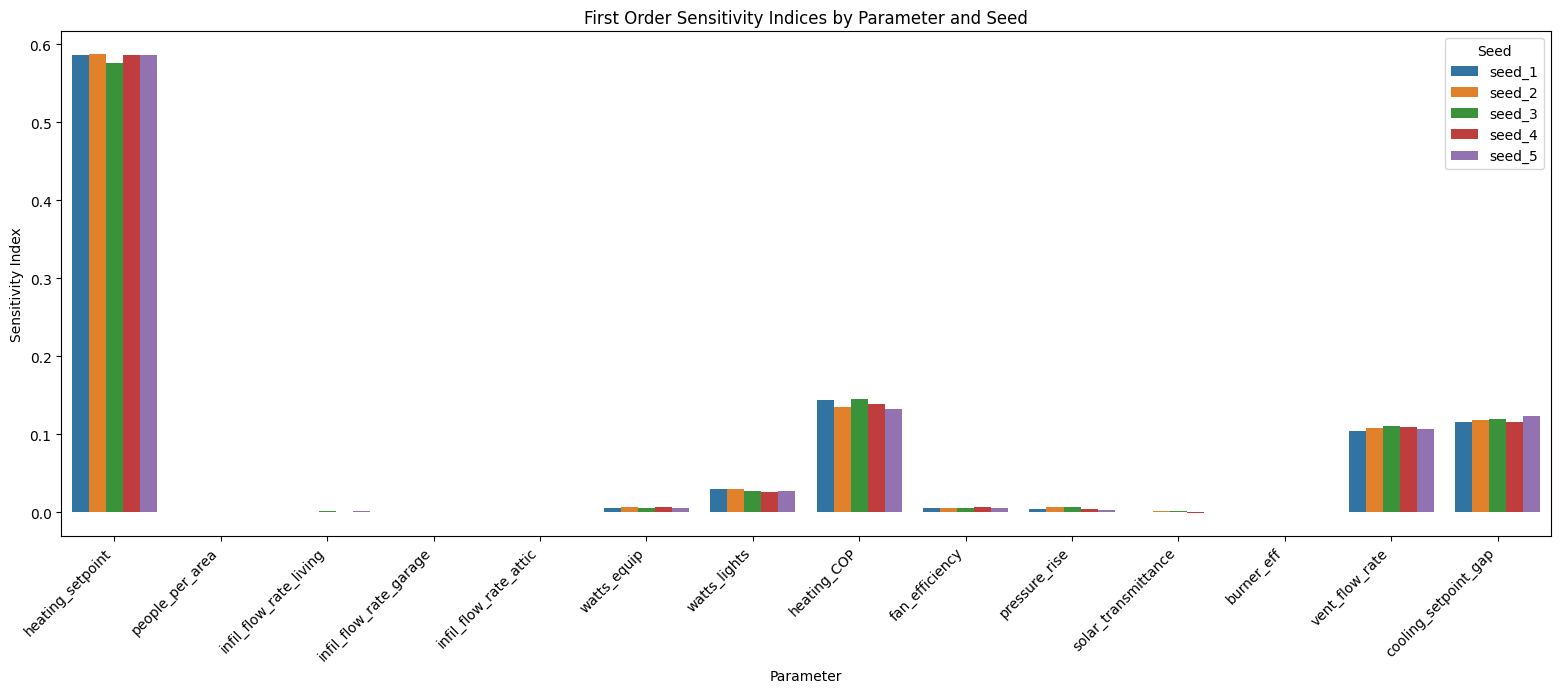

In [21]:
### First Order Sensitivity Indices Plot ### 
def plot_first_order_sensitivity_indices(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    # Seed order
    seed_order = sorted(si_ranks.keys())

    df["seed"] = pd.Categorical(
        df["seed"],
        categories=seed_order,
        ordered=True
    )

    fig = plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="S1",
        hue="seed",
        errorbar=None
    )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("First Order Sensitivity Indices by Parameter and Seed")
    plt.legend(title="Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    fig.savefig(os.path.join(figure_dir, "Standard_Sobol_first_order_sensitivity_indices.png"), dpi=300, bbox_inches="tight")
    plt.show()

plot_first_order_sensitivity_indices(df_all)
# plot_first_order_sensitivity_indices(filter_hs_gap)
# plot_first_order_sensitivity_indices(filter_hs_gap_COP)

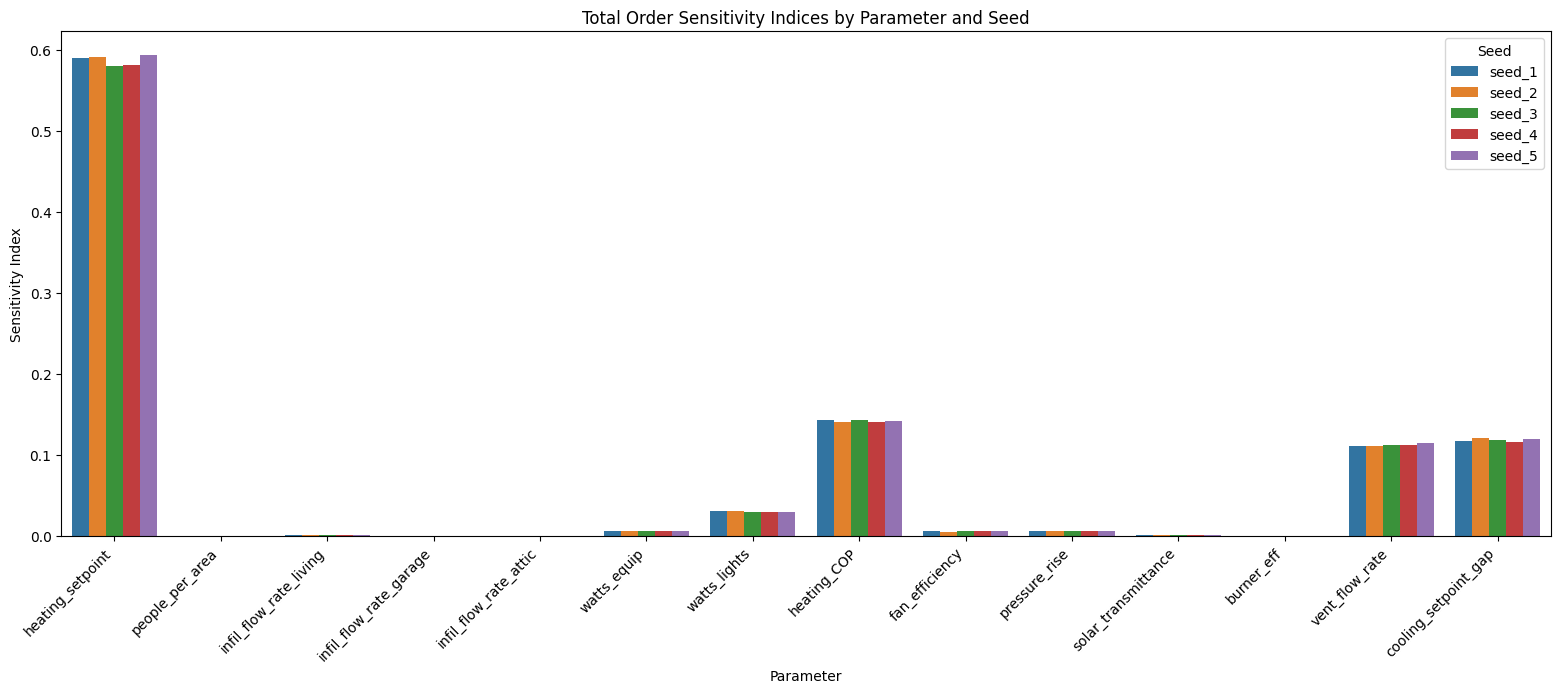

In [22]:
### Total Order Sensitivity Indices Plot ### 
def plot_total_order_sensitivity_indices(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    # Seed order
    seed_order = sorted(si_ranks.keys())

    df["seed"] = pd.Categorical(
        df["seed"],
        categories=seed_order,
        ordered=True
    )

    fig = plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="ST",
        hue="seed",
        errorbar=None
    )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("Total Order Sensitivity Indices by Parameter and Seed")
    plt.legend(title="Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    fig.savefig(os.path.join(figure_dir, "Standard_Sobol_Total_order_sensitivity_indices.png"), dpi=300, bbox_inches="tight")
    plt.show()

plot_total_order_sensitivity_indices(df_all)
# plot_total_order_sensitivity_indices(filter_hs_gap)
# plot_total_order_sensitivity_indices(filter_hs_gap_COP)

In [23]:
### Total Order Sensitivity Indices Singular ### 
def plot_singular_ST(df):
    param_order = df["parameter"].unique()

    df["parameter"] = pd.Categorical(
        df["parameter"],
        categories=param_order,
        ordered=True
    )

    plt.figure(figsize=(16, 6))

    ax = sns.barplot(
        data=df,
        x="parameter",
        y="ST",
    )

    plt.xlabel("Parameter")
    plt.ylabel("Sensitivity Index")
    plt.title("Total Order Sensitivity Indices by Parameter and Seed")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.show()
    

### Comparison to A+BASS Results

In [8]:
import rpy2.robjects as ro

def read_ASBASS_results (seed):
    # Load the file
    ro.r['load'](f'/jumbo/keller-lab/Jeremy_Wang/ASBASSv3/Ranking_Data/14D/24cores/maxuncertainty/seed_{seed}/Sobol_out')
    # Access Sobol_out
    Sobol_out = ro.r['Sobol_out']
    # Confidence Interval bounds
    CI_95_ST = Sobol_out[0]
    mean_ST = Sobol_out[4]
    # creating list for column names
    param_names_ASBASS = parameter_names.copy()
    param_names_ASBASS.remove('cooling_setpoint_gap')
    param_names_ASBASS.insert(1, 'cooling_setpoint_gap')

    reshaped = np.array(CI_95_ST).reshape(2, -1)

    CI_95_ST_df = pd.DataFrame(reshaped, 
                    columns=param_names_ASBASS,
                    index=['lower', 'upper'])  # Label rows as lower/upper CI

    mean_ST_array = np.array(mean_ST)
    mean_95_df = pd.DataFrame(mean_ST_array.reshape(1, -1), columns=param_names_ASBASS)

    return CI_95_ST_df, mean_95_df

In [9]:
asbass_seeds = [31, 32, 33, 34]

means_list = []
ci_list = []

for seed in asbass_seeds:
    CI_df, mean_df = read_ASBASS_results(seed)
    
    mean_df = mean_df.T.reset_index()
    mean_df.columns = ["parameter", "ST"]
    mean_df["seed"] = f"ASBASS_{seed}"
    
    means_list.append(mean_df)
    
    CI_df = CI_df.T.reset_index()
    CI_df.columns = ["parameter", "lower", "upper"]
    CI_df["seed"] = f"ASBASS_{seed}"
    
    ci_list.append(CI_df)

asbass_means = pd.concat(means_list, ignore_index=True)
asbass_ci = pd.concat(ci_list, ignore_index=True)

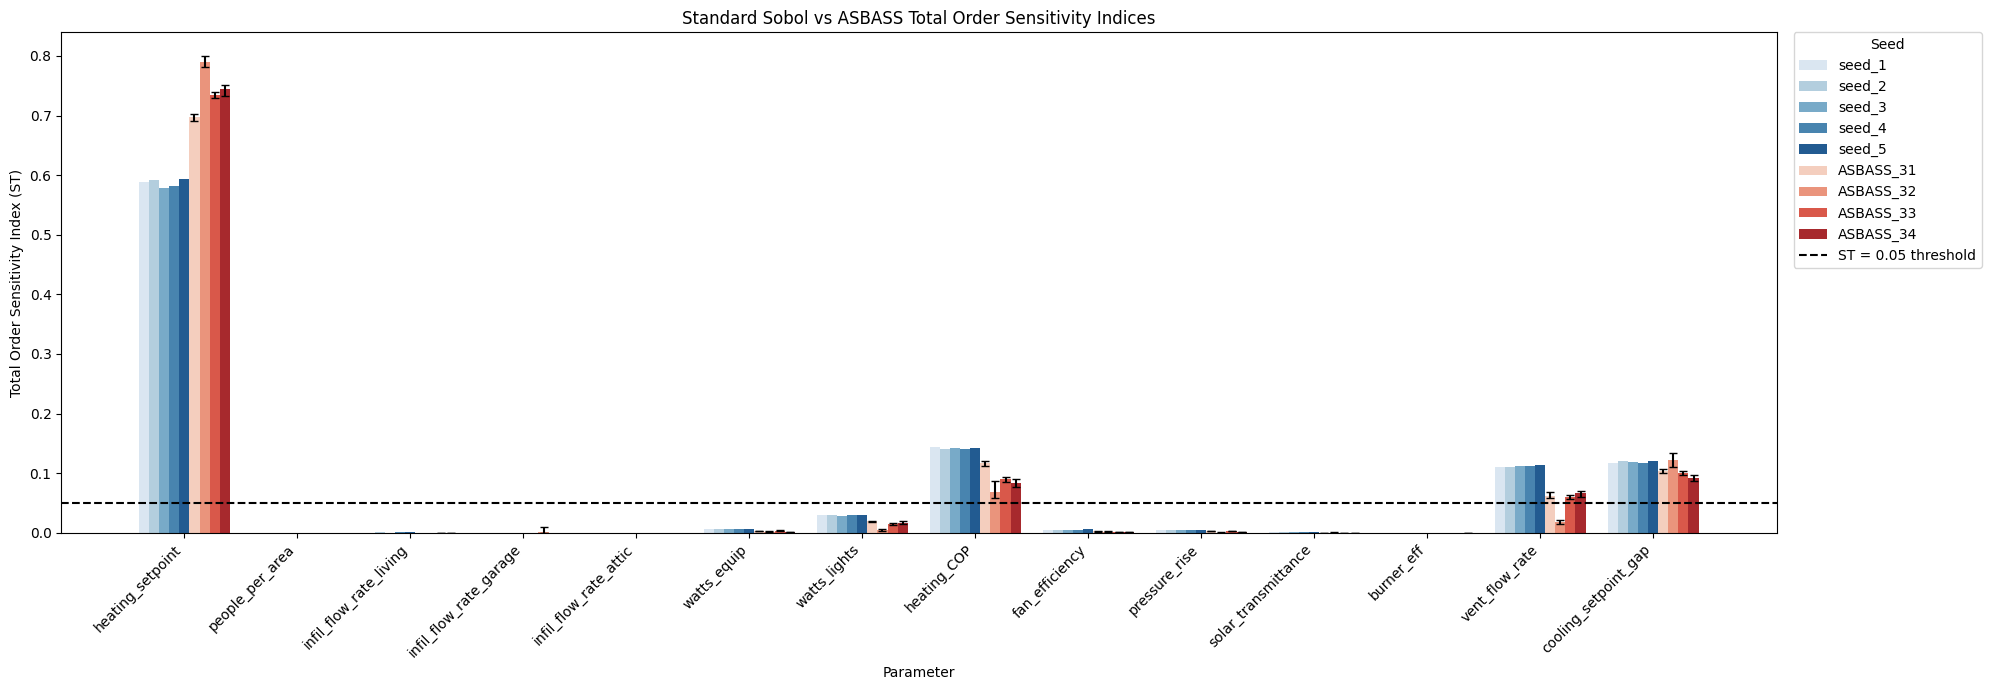

In [10]:
def plot_ASBASS_ST(df_sobol, asbass_means, asbass_ci):
    """
    Plot Total Order Sensitivity Indices for standard Sobol seeds and ASBASS seeds.
    
    Parameters:
    -----------
    df_sobol : pd.DataFrame
        DataFrame with columns ['parameter', 'ST', 'seed'] for standard Sobol results
    asbass_means : pd.DataFrame
        DataFrame with columns ['parameter', 'ST', 'seed'] for ASBASS mean ST values
    asbass_ci : pd.DataFrame
        DataFrame with columns ['parameter', 'lower', 'upper', 'seed'] for ASBASS confidence intervals
    """
    # -------------------------
    # Setup parameter ordering
    # -------------------------
    param_order = df_sobol["parameter"].unique()
    
    # -------------------------
    # Combine both DataFrames for unified hue ordering
    # -------------------------
    sobol_seeds = sorted(df_sobol["seed"].unique())
    asbass_seeds_list = sorted(asbass_means["seed"].unique())
    all_seeds = sobol_seeds + asbass_seeds_list
    
    # Combine into single DataFrame for barplot
    df_sobol_copy = df_sobol.copy()
    df_sobol_copy["parameter"] = pd.Categorical(df_sobol_copy["parameter"], categories=param_order, ordered=True)
    df_sobol_copy["seed"] = pd.Categorical(df_sobol_copy["seed"], categories=all_seeds, ordered=True)
    
    asbass_means_copy = asbass_means.copy()
    asbass_means_copy["parameter"] = pd.Categorical(asbass_means_copy["parameter"], categories=param_order, ordered=True)
    asbass_means_copy["seed"] = pd.Categorical(asbass_means_copy["seed"], categories=all_seeds, ordered=True)
    
    df_combined = pd.concat([df_sobol_copy, asbass_means_copy], ignore_index=True)
    
    # -------------------------
    # Assign colors
    # -------------------------
    sobol_palette = sns.color_palette("Blues", n_colors=len(sobol_seeds))
    asbass_palette = sns.color_palette("Reds", n_colors=len(asbass_seeds_list))
    palette = {seed: color for seed, color in zip(sobol_seeds, sobol_palette)}
    palette.update({seed: color for seed, color in zip(asbass_seeds_list, asbass_palette)})
    
    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(20, 7))
    
    sns.barplot(
        data=df_combined,
        x="parameter",
        y="ST",
        hue="seed",
        palette=palette,
        errorbar=None,
        ax=ax
    )
    
    # -------------------------
    # Add CI error bars for ASBASS seeds
    # -------------------------
    n_total_seeds = len(all_seeds)
    bar_width = 0.8 / n_total_seeds
    
    for i, param in enumerate(param_order):
        for j, asbass_seed in enumerate(asbass_seeds_list):
            # Filter CI data for this param and seed
            ci_row = asbass_ci[(asbass_ci["parameter"] == param) & (asbass_ci["seed"] == asbass_seed)]
            mean_row = asbass_means_copy[(asbass_means_copy["parameter"] == param) & (asbass_means_copy["seed"] == asbass_seed)]
            
            if ci_row.empty or mean_row.empty:
                continue
            
            lower = ci_row["lower"].values[0]
            upper = ci_row["upper"].values[0]
            mean_val = mean_row["ST"].values[0]
            
            # Skip if both bounds are 0
            if lower == 0 and upper == 0:
                continue
            
            err_lower = abs(mean_val - lower)
            err_upper = abs(upper - mean_val)
            
            # Calculate x position: sobol seeds come first, then asbass seeds
            seed_index = all_seeds.index(asbass_seed)
            x_pos = i - 0.4 + (seed_index + 0.5) * bar_width
            
            ax.errorbar(
                x_pos, mean_val,
                yerr=[[err_lower], [err_upper]],
                fmt='none',
                color='black',
                capsize=3,
                linewidth=1.5
            )
    
    # -------------------------
    # Formatting
    # -------------------------
    ax.axhline(y=0.05, color='black', linestyle='--', linewidth=1.5, label='ST = 0.05 threshold')
    
    # Separate legend entries for Sobol vs ASBASS
    handles, labels = ax.get_legend_handles_labels()
    
    # Add custom legend patches for clarity
    threshold_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=1.5, label='ST = 0.05 threshold')
    
    ax.legend(
        handles=handles,
        title="Seed",
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0
    )
    
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Total Order Sensitivity Index (ST)")
    ax.set_title("Standard Sobol vs ASBASS Total Order Sensitivity Indices")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(os.path.join(figure_dir, "Combined_Sobol_ASBASS.png"), dpi=300, bbox_inches="tight")
    plt.show()

plot_ASBASS_ST(df_all, asbass_means, asbass_ci)

### Comparison to AKMCS

In [11]:
def read_AKMCS_results (seed):
    seed_label = f"AKMCS_{seed}"
    # Load the file
    ro.r['load'](f'/jumbo/keller-lab/Jeremy_Wang/ASBASSv3/Ranking_Data/14D/24cores/AKMCS/maxuncertainty/seed_{seed}/Sobol_out')

    # Access Sobol_out
    Sobol_out = ro.r['Sobol_out']

    # Confidence Interval bounds
    CI_95_ST = Sobol_out[0]
    mean_ST = Sobol_out[5]
    # creating list for column names
    param_names_ASBASS = parameter_names.copy()
    param_names_ASBASS.remove('cooling_setpoint_gap')
    param_names_ASBASS.insert(1, 'cooling_setpoint_gap')

    reshaped = np.array(CI_95_ST).reshape(2, -1)

    CI_95_ST_df = pd.DataFrame(reshaped, 
                    columns=param_names_ASBASS,
                    index=['lower', 'upper'])  # Label rows as lower/upper CI

    mean_ST_array = np.array(mean_ST)
    mean_95_df = pd.DataFrame(mean_ST_array.reshape(1, -1), columns=param_names_ASBASS)

    mean_long = mean_95_df.melt(var_name="parameter", value_name="ST")
    mean_long["seed"] = seed_label
    
    # CI values
    ci_long = CI_95_ST_df.T.reset_index()
    ci_long.columns = ["parameter", "lower", "upper"]
    ci_long["seed"] = seed_label
    
    return mean_long, ci_long

akmcs_means, akmcs_ci = read_AKMCS_results(31)


In [15]:
AKMCS_seeds = [31,32,33,34]
akmcs_mean_list = []
akmcs_ci_list = []

for seed in AKMCS_seeds:
    seed_mean, seed_ci = read_AKMCS_results(seed)
    akmcs_mean_list.append(seed_mean)
    akmcs_ci_list.append(seed_ci)

akmcs_means = pd.concat(akmcs_mean_list, ignore_index = True)
akmcs_ci = pd.concat(akmcs_ci_list, ignore_index = True)

In [18]:
akmcs_means

,parameter,ST,seed
0,heating_setpoint,3.460345e-04,AKMCS_31
1,cooling_setpoint_gap,1.030381e-04,AKMCS_31
2,people_per_area,6.798060e-17,AKMCS_31
3,infil_flow_rate_living,7.266784e-01,AKMCS_31
4,infil_flow_rate_garage,7.458036e-15,AKMCS_31
5,infil_flow_rate_attic,8.118336e-15,AKMCS_31
6,watts_equip,1.409675e-09,AKMCS_31
7,watts_lights,6.320221e-09,AKMCS_31
8,heating_COP,1.192234e-03,AKMCS_31
9,fan_efficiency,1.091485e-03,AKMCS_31


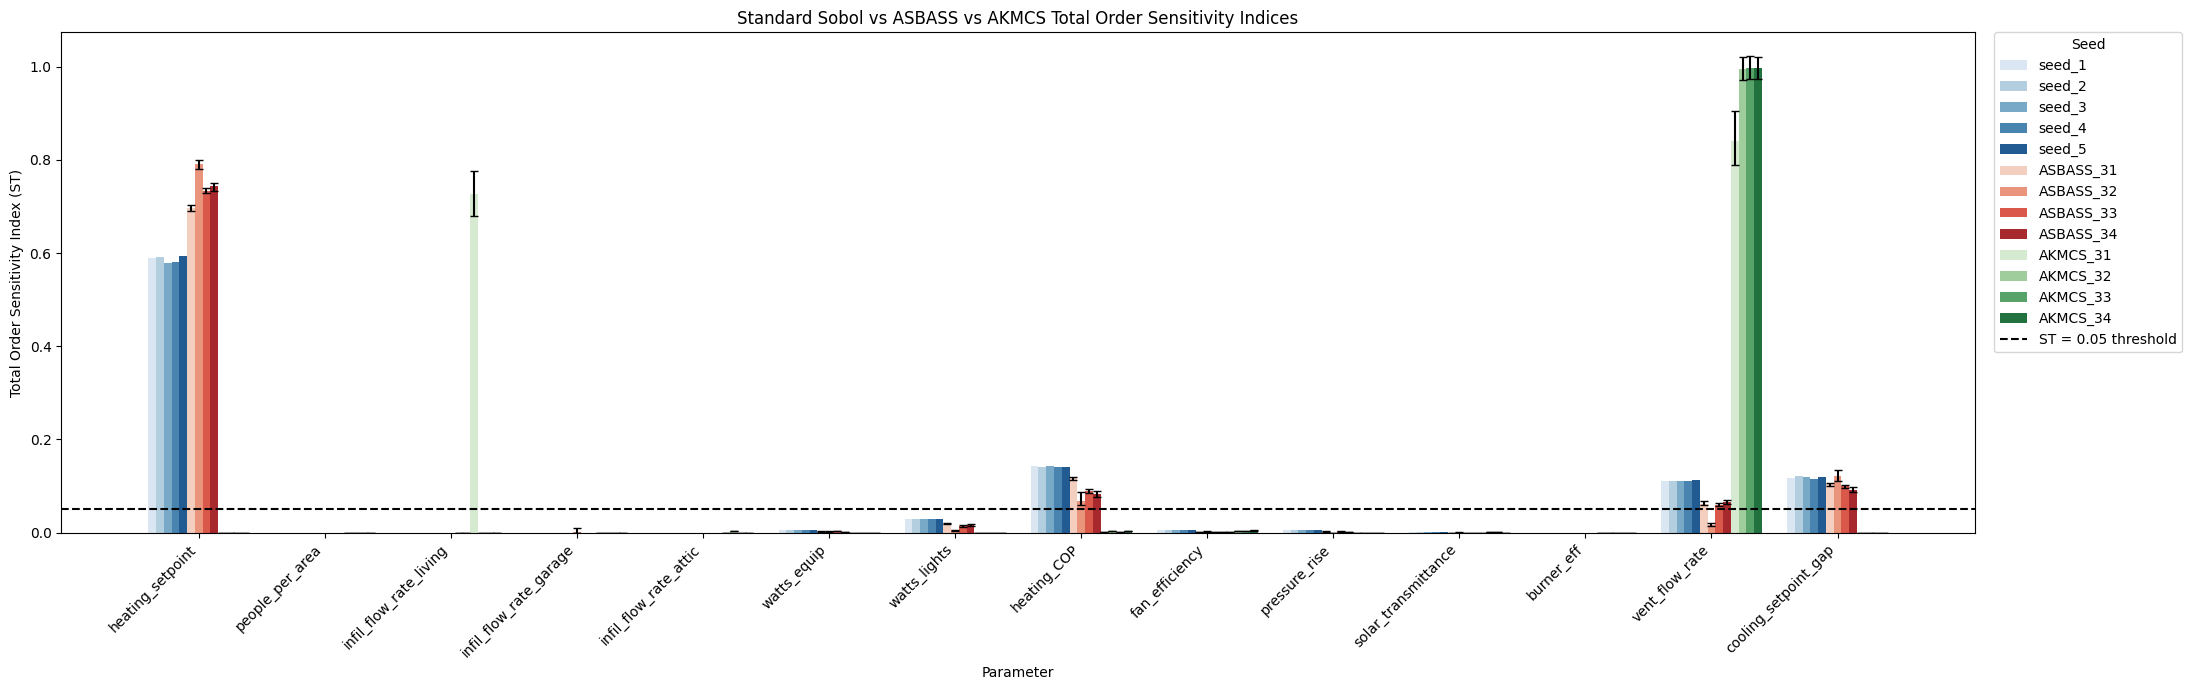

In [17]:
# plot with AKMCS
def plot_AKMCS_ASBASS_ST (df_sobol, asbass_means, asbass_ci,
                                      akmcs_means=None, akmcs_ci=None):
    """
    Plot Total Order Sensitivity Indices for standard Sobol, ASBASS, and AKMCS seeds.
    """
    # Setup parameter ordering
    param_order = df_sobol["parameter"].unique()
    
    # Collect all seeds
    sobol_seeds = sorted(df_sobol["seed"].unique())
    asbass_seeds_list = sorted(asbass_means["seed"].unique())
    akmcs_seeds_list = sorted(akmcs_means["seed"].unique()) if akmcs_means is not None else []
    all_seeds = sobol_seeds + asbass_seeds_list + akmcs_seeds_list
    
    # Prepare Sobol copy
    df_sobol_copy = df_sobol.copy()
    df_sobol_copy["parameter"] = pd.Categorical(df_sobol_copy["parameter"], categories=param_order, ordered=True)
    df_sobol_copy["seed"] = pd.Categorical(df_sobol_copy["seed"], categories=all_seeds, ordered=True)
    
    # Prepare ASBASS copy
    asbass_means_copy = asbass_means.copy()
    asbass_means_copy["parameter"] = pd.Categorical(asbass_means_copy["parameter"], categories=param_order, ordered=True)
    asbass_means_copy["seed"] = pd.Categorical(asbass_means_copy["seed"], categories=all_seeds, ordered=True)
    
    # Prepare AKMCS copy
    frames = [df_sobol_copy, asbass_means_copy]
    if akmcs_means is not None:
        akmcs_means_copy = akmcs_means.copy()
        akmcs_means_copy["parameter"] = pd.Categorical(akmcs_means_copy["parameter"], categories=param_order, ordered=True)
        akmcs_means_copy["seed"] = pd.Categorical(akmcs_means_copy["seed"], categories=all_seeds, ordered=True)
        frames.append(akmcs_means_copy)
    
    df_combined = pd.concat(frames, ignore_index=True)
    
    # Assign colors: Blues for Sobol, Reds for ASBASS, Greens for AKMCS
    sobol_palette = sns.color_palette("Blues", n_colors=len(sobol_seeds))
    asbass_palette = sns.color_palette("Reds", n_colors=len(asbass_seeds_list))
    akmcs_palette = sns.color_palette("Greens", n_colors=len(akmcs_seeds_list))
    
    palette = {seed: color for seed, color in zip(sobol_seeds, sobol_palette)}
    palette.update({seed: color for seed, color in zip(asbass_seeds_list, asbass_palette)})
    palette.update({seed: color for seed, color in zip(akmcs_seeds_list, akmcs_palette)})
    
    # Plot
    fig, ax = plt.subplots(figsize=(22, 7))
    
    sns.barplot(
        data=df_combined,
        x="parameter",
        y="ST",
        hue="seed",
        palette=palette,
        errorbar=None,
        ax=ax
    )
    
    # Add CI error bars for ASBASS and AKMCS
    n_total_seeds = len(all_seeds)
    bar_width = 0.8 / n_total_seeds
    
    # Helper to add error bars for a given set of seeds + CI data
    def add_ci_errorbars(ci_data, means_data, seeds_list):
        for i, param in enumerate(param_order):
            for asbass_seed in seeds_list:
                ci_row = ci_data[(ci_data["parameter"] == param) & (ci_data["seed"] == asbass_seed)]
                mean_row = means_data[(means_data["parameter"] == param) & (means_data["seed"] == asbass_seed)]
                
                if ci_row.empty or mean_row.empty:
                    continue
                
                lower = ci_row["lower"].values[0]
                upper = ci_row["upper"].values[0]
                mean_val = mean_row["ST"].values[0]
                
                if lower == 0 and upper == 0:
                    continue
                
                err_lower = abs(mean_val - lower)
                err_upper = abs(upper - mean_val)
                
                seed_index = all_seeds.index(asbass_seed)
                x_pos = i - 0.4 + (seed_index + 0.5) * bar_width
                
                ax.errorbar(
                    x_pos, mean_val,
                    yerr=[[err_lower], [err_upper]],
                    fmt='none',
                    color='black',
                    capsize=3,
                    linewidth=1.5
                )
    
    # ASBASS error bars
    add_ci_errorbars(asbass_ci, asbass_means_copy, asbass_seeds_list)
    
    # AKMCS error bars
    if akmcs_ci is not None and akmcs_means is not None:
        add_ci_errorbars(akmcs_ci, akmcs_means_copy, akmcs_seeds_list)
    
    # Formatting
    ax.axhline(y=0.05, color='black', linestyle='--', linewidth=1.5, label='ST = 0.05 threshold')
    
    handles, labels = ax.get_legend_handles_labels()
    threshold_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=1.5, label='ST = 0.05 threshold')
    
    # Add group labels to legend
    sobol_patch = mpatches.Patch(color='steelblue', alpha=0.5, label='── Sobol ──')
    asbass_patch = mpatches.Patch(color='indianred', alpha=0.5, label='── ASBASS ──')
    akmcs_patch = mpatches.Patch(color='seagreen', alpha=0.5, label='── AKMCS ──')
    
    ax.legend(
        handles=handles,
        title="Seed",
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0
    )
    
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Total Order Sensitivity Index (ST)")
    ax.set_title("Standard Sobol vs ASBASS vs AKMCS Total Order Sensitivity Indices")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(os.path.join(figure_dir, "Combined_Sobol_ASBASS_AKMCS.png"), dpi=300, bbox_inches="tight")
    plt.show()

plot_AKMCS_ASBASS_ST(
    df_all, asbass_means, asbass_ci,
    akmcs_means=akmcs_means, akmcs_ci=akmcs_ci
)

### Screening Checks

In [11]:
# dictionary to hold screened parameters
seeds = [f"seed_{i}" for i in range(1,6)]
sobol_screening = {}
screen_threshold = 0.05

# determining which parameters are above threshold based on lower bound of 95% CI
for seed in seeds:
    indices_dict = sobol_indices[seed]
    ST = indices_dict['ST']
    ST_conf = indices_dict['ST_conf']
    CI_lower = ST - ST_conf
    
    sobol_screening[seed] = []
    for ci_lower, param_name in zip(CI_lower, parameter_names):
        if ci_lower >= screen_threshold:
            sobol_screening[seed].append(param_name)

# creating list for column names
param_names_ASBASS = parameter_names.copy()
param_names_ASBASS.remove('cooling_setpoint_gap')
param_names_ASBASS.insert(1, 'cooling_setpoint_gap')

# determing which parameters are above threshold for R results
ASBASS_screening = {}
for seed in asbass_seeds:
    ASBASS_screening[f'seed_{seed}'] = []
    seed_name = f'ASBASS_{seed}'
    for param in param_names_ASBASS:
        row = asbass_means[
            (asbass_means['parameter'] == param) &
            (asbass_means['seed'] == seed_name)
        ]
        indice = row['ST'].values[0]
        if indice >= screen_threshold:
            ASBASS_screening[f'seed_{seed}'].append(param)

In [12]:
ASBASS_screening

{'seed_31': ['heating_setpoint',
  'cooling_setpoint_gap',
  'heating_COP',
  'vent_flow_rate'],
 'seed_32': ['heating_setpoint', 'cooling_setpoint_gap', 'heating_COP'],
 'seed_33': ['heating_setpoint',
  'cooling_setpoint_gap',
  'heating_COP',
  'vent_flow_rate'],
 'seed_34': ['heating_setpoint',
  'cooling_setpoint_gap',
  'heating_COP',
  'vent_flow_rate']}

In [13]:
sobol_screening

{'seed_1': ['heating_setpoint',
  'heating_COP',
  'vent_flow_rate',
  'cooling_setpoint_gap'],
 'seed_2': ['heating_setpoint',
  'heating_COP',
  'vent_flow_rate',
  'cooling_setpoint_gap'],
 'seed_3': ['heating_setpoint',
  'heating_COP',
  'vent_flow_rate',
  'cooling_setpoint_gap'],
 'seed_4': ['heating_setpoint',
  'heating_COP',
  'vent_flow_rate',
  'cooling_setpoint_gap'],
 'seed_5': ['heating_setpoint',
  'heating_COP',
  'vent_flow_rate',
  'cooling_setpoint_gap']}